# Axe 3 — Satisfaction & implication

Dans ce notebook, j'étudie les variables liées aux facteurs subjectifs des employés (le ressenti et l'investissement) afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes avec les autres axe 
- de visualiser
- retenir seulement ce qui ressort clairement
---
**Remarque a moi**
Pourquoi, à conditions égales, certains partent et d’autres non ?

## 1. Exploration desciptive des variables de l’axe
---

### 1.1 Import des librairies & chargement des données
---

In [2]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# chargement du df
df_clean = pd.read_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet")
df_clean.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


### 1.2 Fonctions utilitaires

In [4]:
# Tableau de pourcentage variable univarié

def value_counts_percent(serie,round_n=3):

    """  Calcule la distribution (%) d'une variable catégorielle et retourne un DataFrame"""
    
    return (serie.value_counts(normalize=True).
            round(round_n).
            mul(100).
            reset_index(name="Pourcentage"))

# Tableau de pourcentage de variables bivariés
def groupby_percent(df,columns1,columns2,observed=True):
    """Calcule la distribution (%) de columns2 pour chaque modalité de columns1
    et retourne un DataFrame au format long. """
    return(df.groupby(columns1,observed=observed)[columns2].
           value_counts(normalize=True).
           round(2)
           *100).reset_index(name="Pourcentage")

# Table pivot en pourcentage de variables bivarié
def pivot_percent(df,index,columns):
    """ Crée un tableau pivot (%) : lignes=index, colonnes=columns."""
    df = groupby_percent(df,index,columns)
    return(df.pivot(index=index, columns=columns,values="Pourcentage").fillna(0))




### 1.3 Creation du DataFrame satisfaction_implication
---
#### Colonnes incluses dans l'axe "Satisfaction et implication"

Cet axe regroupe les caractéristiques du ressenti et de l'investissement des employés dans la structure:
- JobInvolvement 
- EnvironmentSatisfaction 
- JobSatisfaction 
- PerformanceRating 
- RelationshipSatisfaction
- WorkLifeBalance 


In [5]:
# colonnes condition de travail
cols_satisfaction_implication = ['JobInvolvement', 'EnvironmentSatisfaction','JobSatisfaction',"PerformanceRating",'RelationshipSatisfaction','WorkLifeBalance']

# creation df_condition_Trav
df_satisfaction_implication = df_clean[cols_satisfaction_implication + ['Attrition']].copy()
df_satisfaction_implication.head(3)

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,Attrition
0,3,2,4,3,1,1,Yes
1,2,3,2,4,4,3,No
2,2,4,3,3,2,3,Yes


#### 1.3.1 Préparation des variables



##### Renommage des codage et échelle des variables

Toutes les variables de cet axe sont codées sur une échelle ordinale de 1 à 4.  
Une valeur plus élevée correspond systématiquement à une perception ou une évaluation plus positive, bien que les libellés diffèrent légèrement selon la variable.

#### Variables de satisfaction (environnement, relations, travail)

- **EnvironmentSatisfaction**  
  - 1 : Faible satisfaction  
  - 2 : Satisfaction moyenne  
  - 3 : Satisfaction élevée  
  - 4 : Satisfaction très élevée  

- **JobSatisfaction**  
  - 1 : Faible satisfaction au travail  
  - 2 : Satisfaction moyenne  
  - 3 : Satisfaction élevée  
  - 4 : Satisfaction très élevée  

- **RelationshipSatisfaction**  
  - 1 : Faible satisfaction des relations professionnelles  
  - 2 : Satisfaction moyenne  
  - 3 : Satisfaction élevée  
  - 4 : Satisfaction très élevée  

- **WorkLifeBalance**  
  - 1 : Équilibre vie professionnelle / personnelle insatisfaisant  
  - 2 : Équilibre satisfaisant  
  - 3 : Bon équilibre  
  - 4 : Excellent équilibre  

#### Variables d’engagement et de performance

- **JobInvolvement**  
  - 1 : Faible engagement professionnel  
  - 2 : Engagement modéré  
  - 3 : Engagement élevé  
  - 4 : Engagement très élevé  

- **PerformanceRating**  
  - 1 : Performance faible  
  - 2 : Bonne performance  
  - 3 : Excellente performance  
  - 4 : Performance exceptionnelle  

**Remarque** : *PerformanceRating* mesure un résultat observable et ne doit pas être assimilée directement à la satisfaction ou à la motivation.

In [104]:
# Satisfaction_label

satifaction_label = {1 : "Faible",
                    2 :  "Moyenne",
                    3 : "Élevée",
                    4 : "Trés élevée"}

df_satisfaction_implication[["EnvironmentSatisfaction_label","JobSatisfaction_label","RelationshipSatisfaction_label"]] = df_satisfaction_implication[["EnvironmentSatisfaction","JobSatisfaction","RelationshipSatisfaction"]].replace(satifaction_label)

# worklifebalance
worklife_label =   {1: "Insatisfaisant",
                    2: "Satisfaisant",
                    3: "Bon",
                    4: "Excellent"}


df_satisfaction_implication["WorkLifeBalance_label"] = df_satisfaction_implication["WorkLifeBalance"].replace(worklife_label)

# engagement_label

JobInvolvement_label =  {1 : "Faible",
                        2 :  "Modéré",
                        3 : "Élevé",
                        4 : "Trés élevé"}

df_satisfaction_implication["JobInvolvement_label"] = df_satisfaction_implication["JobInvolvement"].replace(JobInvolvement_label)

# PerformanceRating

PerformanceRating_label =  {1 : "Faible",
                            2 : "Bonne",
                            3 : "Excellente",
                            4 : "Exceptionnelle"}
df_satisfaction_implication["PerformanceRating_label"] = df_satisfaction_implication["PerformanceRating"].replace(PerformanceRating_label)

df_satisfaction_implication.head()

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,Attrition,EnvironmentSatisfaction_label,JobSatisfaction_label,RelationshipSatisfaction_label,WorkLifeBalance_label,JobInvolvement_label,PerformanceRating_label
0,3,2,4,3,1,1,Yes,Moyenne,Trés élevée,Faible,Insatisfaisant,Élevé,Excellente
1,2,3,2,4,4,3,No,Élevée,Moyenne,Trés élevée,Bon,Modéré,Exceptionnelle
2,2,4,3,3,2,3,Yes,Trés élevée,Élevée,Moyenne,Bon,Modéré,Excellente
3,3,4,3,3,3,3,No,Trés élevée,Élevée,Élevée,Bon,Élevé,Excellente
4,3,1,2,3,4,3,No,Faible,Moyenne,Trés élevée,Bon,Élevé,Excellente


### 1.4  Analyse individuelle des variables 
---
Dans cette section, l’analyse porte sur plusieurs caractéristiques de la satisfaction et de l'implication des employés, afin de mieux comprendre le contexte organisationnel de la population étudiée.

Les variables sont analysées selon deux sous-thèmes :
- la satisfaction :  perception et ressenti (environnement, relations, équilibre)
- l'implication : comportement et investissement

Certaines variables seront analysées de manière plus approfondie que d’autres.
Cette analyse repose sur une approche **descriptive**, basée sur l’étude des **distributions**, à l’aide de **tableaux de proportions** et de **visualisations graphiques**.

Pour compléter l’analyse catégorielle, une moyenne des scores de satisfaction et d’implication est calculée comme indicateur synthétique.


#### 1.4.1 La satisfaction
---
Dans cette section, **la satisfaction au travail** est analysée à travers plusieurs dimensions complémentaires : l’environnement de travail, le poste occupé, les relations professionnelles et l’équilibre entre vie professionnelle et vie personnelle.

Les variables étudiées sont les suivantes :

- **EnvironmentSatisfaction** : niveau de satisfaction vis-à-vis de l’environnement et des conditions de travail  
- **JobSatisfaction** : e niveau de satisfaction des employés concernant leur poste et le travail qu’ils exercent.  
- **RelationshipSatisfaction** : niveau de satisfaction des relations professionnelles (collègues, manager)  
- **WorkLifeBalance** : niveau de satisfaction concernant l’équilibre entre vie professionnelle et vie personnelle


Dans le cadre de cette analyse :
- **EnvironmentSatifaction** et **RelationshipSatisfaction** feront l’objet d’une analyse descriptive légère.
-  **JobSatisfaction** et **WorkLifeBalance** seront analysées de manière plus détaillée.


Les variables de ce sous-thème sont décrites à travers leurs répartitions afin de mieux comprendre la structure des postes au sein de l’entreprise.

##### 1.4.1.1 Le niveau de satisfaction vis-à-vis de l’environnement et des conditions de travail 

##### Tableau des proportions

In [43]:
environmentSatisfaction_count = value_counts_percent(df_satisfaction_implication["EnvironmentSatisfaction_label"])
environmentSatisfaction_count

,EnvironmentSatisfaction_label,Pourcentage
0,Élevée,30.8
1,Très élevée,30.3
2,Moyenne,19.5
3,Faible,19.3


On observe qu'une majorité des employés environ **61 %**  déclarent un niveau de satisfaction vis à vis de l'environnement et des conditions de travail **élévée** (≈ 31 % )ou **trés élevée** (≈ 30 %).

À l’inverse, les niveaux les moins représentés sont les niveaux de satisfaction **faible** (≈ 20%) et **moyenne** (≈ 19%).

Cette exploration met en évidence les grandes lignes d'un élément contextuel de la satifaction au travail.

##### 1.4.1.2 Le niveau de satisfaction vis-à-vis du poste

##### Tableau des proportions

In [74]:


jobSatisfaction_count = value_counts_percent(df_satisfaction_implication["JobSatisfaction_label"])
display(jobSatisfaction_count)


display(f'La moyenne du niveau de satifaction lié au travail exercé des employés est de {df_satisfaction_implication["JobSatisfaction"].mean().round(2)} soit une satifaction qui tend vers élevé')
display(f'La mediane du niveau de satifaction lié au travail exercé des employés est de {df_satisfaction_implication["JobSatisfaction"].median().round(2)} soit une satifaction élevé')

,JobSatisfaction_label,Pourcentage
0,Très élevée,31.2
1,Élevée,30.1
2,Faible,19.7
3,Moyenne,19.0


'La moyenne du niveau de satifaction lié au travail exercé des employés est de 2.73 soit une satifaction qui tend vers élevé'

'La mediane du niveau de satifaction lié au travail exercé des employés est de 3.0 soit une satifaction élevé'

##### Répartitions des employés selon leur niveau de satisfaction liée au poste

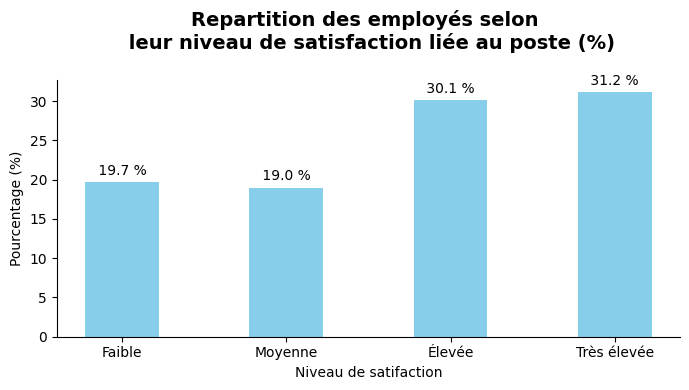

(None,)

In [98]:

# Catégorie ordonnées
## nettoyé
jobSatisfaction_count["JobSatisfaction_label"] = (jobSatisfaction_count["JobSatisfaction_label"].astype(str).str.strip().replace({"Trés élevée": "Très élevée"}))

## ordre
ordre_satisfaction = ["Faible", "Moyenne", "Élevée", "Très élevée"]

## Convertir 
jobSatisfaction_count["JobSatisfaction_label"] = pd.Categorical(
    jobSatisfaction_count["JobSatisfaction_label"],
    categories=ordre_satisfaction,
    ordered=True
)

# Trier
jobSatisfaction_count = jobSatisfaction_count.sort_values("JobSatisfaction_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(jobSatisfaction_count.index))
y = jobSatisfaction_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(jobSatisfaction_count["JobSatisfaction_label"])

ax.set_xlabel("Niveau de satifaction")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon \n leur niveau de satisfaction liée au poste (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


Ce graphique met en évidence deux niveaux de satisfaction liés au travail exercé particulièrement représentés :
- **trés élevée** (≈ 31 %)
- **élevée** (≈ 30 % )

À l’inverse, les niveaux de satisfaction **faible** et **moyen** sont moins représentés, chacun concernant environ 19 à 20 % des employés.

La moyenne des niveaux de satisfaction est de **2,73**, indiquant un niveau global tendant vers une satisfaction élevée.

Cette exploration fournit une première vision du niveau de satisfaction professionnelle lié au poste occupé au sein de l’entreprise.
La majorité des salariés déclarent ainsi un niveau de satisfaction **élevé ou très élevé**, suggérant un vécu professionnel globalement favorable.

##### 1.4.1.3 Le niveau de satisfaction des relations professionnelles (collègues, manager)

##### Tableau des proportions

In [44]:
relationshipSatisfaction_count = value_counts_percent(df_satisfaction_implication["RelationshipSatisfaction_label"])
relationshipSatisfaction_count

,RelationshipSatisfaction_label,Pourcentage
0,Élevée,31.2
1,Très élevée,29.4
2,Moyenne,20.6
3,Faible,18.8


On observe qu’une large majorité des employés déclarent un niveau de satisfaction **élevé ou très élevé** concernant leurs relations professionnelles, soit environ **62 %** de l’effectif.

À l’inverse, les niveaux de satisfaction **moyen et faible** sont moins représentés, chacun concernant environ **19 à 20 %** des employés.

##### 1.4.1.4 Le niveau de satisfaction concernant l’équilibre entre vie professionnelle et vie personnelle

##### Tableau des proportions

In [91]:
workLifeBalance_count = value_counts_percent(df_satisfaction_implication["WorkLifeBalance_label"])
display(workLifeBalance_count)


display(f"La moyenne du niveau de satifaction entre l'équilibre vie pro/perso est de {df_satisfaction_implication["WorkLifeBalance"].mean().round(2)} soit un équilibre qui tend vers un bon équilibre")
display(f"La médiane du niveau de satifaction entre l'équilibre vie pro/perso est de {df_satisfaction_implication["WorkLifeBalance"].median().round(2)} soit un bon équilibre")

,WorkLifeBalance_label,Pourcentage
0,Bon,60.7
1,Satisfaisant,23.4
2,Excellent,10.4
3,Insatisfaisant,5.4


"La moyenne du niveau de satifaction entre l'équilibre vie pro/perso est de 2.76 soit un équilibre qui tend vers un bon équilibre"

"La médiane du niveau de satifaction entre l'équilibre vie pro/perso est de 3.0 soit un bon équilibre"

##### Répartitions des employés en fonctions

Ce graphique met en évidence qu’un niveau d’équilibre entre vie professionnelle et vie personnelle est particulièrement représenté : le niveau **bon équilibre**, déclaré par environ **61 %** des employés.

À l’inverse, le niveau équilibre **insatisfaisant** apparaît comme le plus minoritaire, avec environ **5 %** des déclarations.

Cette exploration fournit une première échelle de lecture du ressenti des salariés concernant l’équilibre vie professionnelle / vie personnelle.
La majorité des salariés déclarent ainsi un équilibre satisfaisant, suggérant une perception globalement positive de cette dimension.

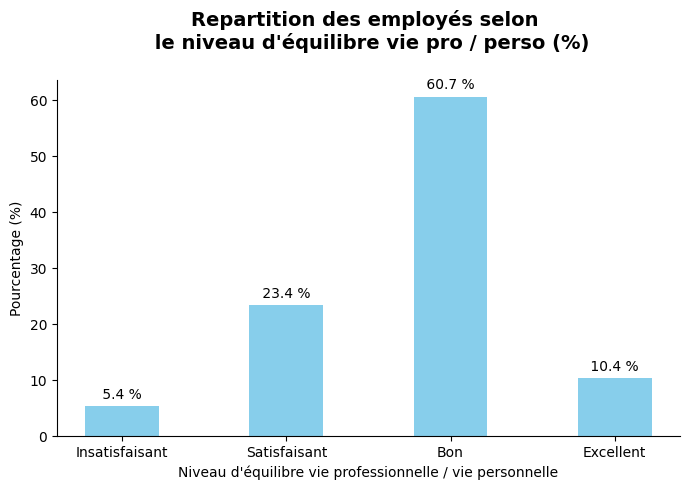

(None,)

In [102]:

# Catégorie ordonnées
## nettoyé
workLifeBalance_count["WorkLifeBalance_label"] = ( workLifeBalance_count["WorkLifeBalance_label"].astype(str).str.strip())

## ordre
ordre_equilibre = ["Insatisfaisant","Satisfaisant", "Bon", "Excellent"]

## Convertir 
workLifeBalance_count["WorkLifeBalance_label"] = pd.Categorical(
    workLifeBalance_count["WorkLifeBalance_label"],
    categories=ordre_equilibre,
    ordered=True)

# Trier
workLifeBalance_count = workLifeBalance_count.sort_values("WorkLifeBalance_label", ascending=True)

# Graphique

fig , ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(workLifeBalance_count.index))
y = workLifeBalance_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(workLifeBalance_count["WorkLifeBalance_label"])

ax.set_xlabel("Niveau d'équilibre vie professionnelle / vie personnelle")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon \n le niveau d'équilibre vie pro / perso (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


fig, ax = pl

**Mini-synthèse - Satisfaction**

L’analyse de la satisfaction montre qu’une large majorité des employés déclarent un niveau de satisfaction **élevé à très élevé**, aussi bien concernant leur poste, leur environnement de travail que leurs relations professionnelles.

Cette tendance se retrouve également dans l’équilibre vie professionnelle / vie personnelle, avec une majorité de salariés déclarant disposer d’un **bon équilibre**.

#### 1.4.2 Implication
---
Cette section s’intéresse aux variables liées à la **l'inplication et l'investissement** des employés.

Les variables analysées sont :

- **JobInvolvement** : niveau d’engagement professionnel de l’employé dans son travail  
- **PerformanceRating** : évaluation du niveau de performance observée  
  *(proxy indirect de l’engagement, à interpréter avec prudence)* 

L’analyse conjointe de JobInvolvement et PerformanceRating permet de distinguer l’engagement perçu par le salarié de la performance évaluée par l’entreprise.

Dans le cadre de cette analyse :
- **JobInvolvement** fera l’objet d’une analyse descriptive légère.
- **PerformanceRating***  sera analysées de manière plus détaillée.

 
Ces variables sont analysées de manière descriptive afin de caractériser la distribution des niveaux de rémunération au sein de l’entreprise.

##### 1.4.2.1 Le niveau d'engagement professionnel des employés

##### Tableau des proportions

In [106]:
jobInvolvement_count = value_counts_percent(df_satisfaction_implication["JobInvolvement_label"])
display(jobInvolvement_count)

display(f"La moyenne du niveau d'engagement des employés est de {df_satisfaction_implication["JobInvolvement"].mean().round(2)} soit une implication qui tend vers un niveau élevé")
display(f"La médiane du niveau d'engagement des employés est de {df_satisfaction_implication["JobInvolvement"].median().round(2)} soit une une implication d'un niveau élevé")

,JobInvolvement_label,Pourcentage
0,Élevé,59.0
1,Modéré,25.5
2,Trés élevé,9.8
3,Faible,5.6


"La moyenne du niveau d'engagement des employés est de 2.73 soit une implication qui tend vers un niveau élevé"

"La médiane du niveau d'engagement des employés est de 3.0 soit une une implication d'un niveau élevé"

##### Répartitions des employés en fonctions de leur niveau d'engagement professionnelle.

Ce graphique met en évidence qu’un niveau d’engagement professionnel est particulièrement représenté : **environ 59 %** des employés déclarent un niveau d’engagement **élevé**.

À l’inverse, les niveaux d’engagement **faible** (≈ 6 %) et **très élevé**(≈ 10 %) sont plus minoritaires.

La moyenne du niveau d’engagement tend vers un niveau **élevé**, indiquant une implication professionnelle globalement importante au sein de la population étudiée.

Cette exploration fournit une première lecture de la perception qu’ont les salariés de leur propre niveau d’implication.


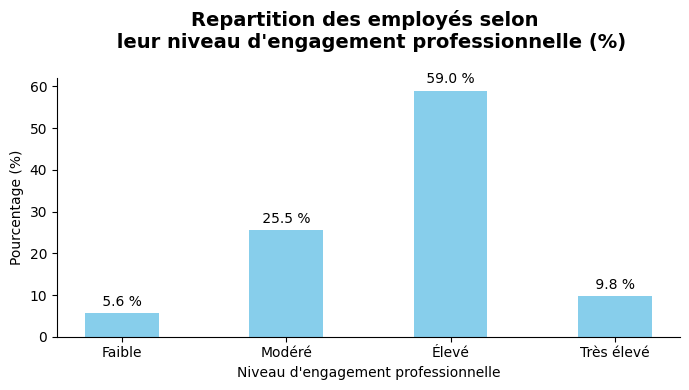

(None,)

In [107]:
# Catégorie ordonnées
## nettoyé
jobInvolvement_count["JobInvolvement_label"] = (jobInvolvement_count["JobInvolvement_label"].astype(str).str.strip().replace({"Trés élevé": "Très élevé"}))

## ordre
ordre_jobInvolvement = ["Faible", "Modéré", "Élevé", "Très élevé"]

## Convertir 
jobInvolvement_count["JobInvolvement_label"] = pd.Categorical(
    jobInvolvement_count["JobInvolvement_label"],
    categories=ordre_jobInvolvement,
    ordered=True
)

# Trier
jobInvolvement_count = jobInvolvement_count.sort_values("JobInvolvement_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(jobInvolvement_count.index))
y = jobInvolvement_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(jobInvolvement_count["JobInvolvement_label"])

ax.set_xlabel("Niveau d'engagement professionnelle")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon \n leur niveau d'engagement professionnelle (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


##### 1.4.2.2 L'évaluation du niveau de performance observée

##### Tableau des proportions

In [55]:
performanceRating_count = value_counts_percent(df_satisfaction_implication["PerformanceRating_label"])
performanceRating_count

,PerformanceRating_label,Pourcentage
0,Excellente,84.6
1,Exceptionnelle,15.4


On observe que seuls deux niveaux d’évaluation de la performance sont représentés : **Excellente** et **Exceptionnelle**.

Le niveau **Excellente** est largement majoritaire, concernant environ **85 %** de la population.

**Mini-synthèse - implication**

L’analyse de l’implication met en évidence qu’une large majorité des employés déclarent un niveau d’engagement professionnel **élevé**.

Cette tendance est également observée dans l’évaluation de la performance, la majorité des salariés étant classée à un niveau de performance **élevé**.

Après avoir décrit les principales caractéristiques de la satification et implication des employés, cette section s’intéresse désormais à leur relation avec l’attrition.

L’objectif est d’observer si certaines dimensions subjective  telles que la satisfaction et l'implication présentent des différences de taux d’attrition selon les groupes étudiés.



## 2. Attrition - Satifcation/Implication
---

### 2.1 Introduction
---
Dans cette section, je compare la variable cible, l’attrition, aux variables des conditions de travail analysées précédemment, afin d’identifier d’éventuelles relations entre ces caractéristiques et le départ des employés.

##### Tableau de proportions Attrition Yes / No

In [7]:
attrition = df_satisfaction_implication['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100

df_attrition = attrition.reset_index()
df_attrition.columns = ['Attrition', "Pourcentage"]

df_attrition

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D’après ce tableau, le taux d’attrition global observé dans le jeu de données est d’environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.
Dans les analyses suivantes, l’accent est mis sur le taux d’attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 2.2 Analyse de l’attrition selon les variables de la satisfaction et l'implication
---
Dans cet partie, les sous themes précedent sont réutilisé pour analyser les variables avec l'attrition.

Certaines variables de cet axes ont été explorées individuellement mais n’ont pas été retenues dans l’analyse de l’attrition, en raison de distributions peu contrastées ou d’un intérêt analytique limité observé lors de l’exploration initiale.

Les variables sélectionnées sont comparées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.  
Cette approche permet d’identifier des différences de taux d’attrition entre les groupes avant toute analyse approfondie.

#### 2.2.1 Attrition et la satisfaction
---

Dans cette partie, les variables analysé avec l'attrition sont  


##### 2.2.1.1 Attrition et 
---

##### Tableau de proportions ­­

##### Graphique — Analyse de la relation entre le poste occupé et l'attrition

***Observation descriptive***

#### 2.2.1.2 Attrition et 
---

##### Tableau de proportions ­­

##### Graphique — Analyse de la relation entre les heures supplémentaires et l'attrition

***Observation descriptive***

#### 2.2.2 Attrition et l'implication
---

Dans cette partie, les variables analysé avec l'attrition sont 


#### 2.2.2.1 Attrition et 
---

##### Tableau de proportions ­­

##### Graphique — Analyse de la relation entre le revenu mensuel et l'attrition

***Observation descriptive***

#### 2.2.2.2 Attrition et 
---

##### Tableau de proportions ­­

***Observation descriptive***

#### 2.3 Résultats clés - Satisfaction /implication et attrition
---


Une fois les comparaisons simples réalisées, j’explore les facteurs explicatif à l’axe afin d’identifier d’éventuels patterns ou corrélations.

## 3. Facteurs associés à la satisfaction et à l’implication
----

### 3.1 Introduction

Cette section vise à identifier les facteurs organisationnels ou individuels associés aux niveaux de satisfaction et d’implication, afin de mieux contextualiser les résultats observés sur l’attrition.

l'analyse portera sur trois ou quatre relation, qui m'ont semblé pertinent d'etudier afin de donner du contexte au résultat de l'attriton deja observé :

- 
- 
- 
---
**Remarque moi**
Satisfaction × quelques variables clés de l’axe 2
Implication × quelques variables clés de l’axe 2
Éventuellement 1 variable perso

### 3.2 Analyse des relations entre Satisfaction/ implication et les variables organisationnelles
---

Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.

#### 3.2.1 Relation entre 
---

##### Tableaux croisés (%)

##### Visualisation


***Observation descriptive***

#### 3.2.2 Relation entre 
---


##### Tableaux croisés (%)

##### Visualisation

***Observation descriptive***

#### 3.2.3 Relation 
---


##### Tableau croisé (%)

##### Visualisation



***Observation descriptive***

### 3.3 Analyse des relations entre Satisfaction/ implication et les variables individuelle
---

Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.

#### 3.2.1 Relation entre 
---

##### Tableaux croisés (%)

##### Visualisation


***Observation descriptive***

Après avoir analysé ces relations, cette section synthétise les principaux patterns observés.

### 3.4 Synthèse des Patterns transversaux
---



# 4. Résultats clés 
---


---


# 5. Conclusion de l’axe “Condition de travail”
---
